<a href="https://colab.research.google.com/github/Rahul7587/invoice-ocr-application/blob/main/notebooks/invoice_ocr_evaluation_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Invoice OCR evaluation — corrected pipeline

This notebook evaluates Tesseract on the invoice dataset using the annotated fields `company`, `date`, `address`, and `total`.

The important fixes are:

- one consistent Tesseract configuration;
- no forced adaptive thresholding as the default;
- extraction based on invoice layout rather than an `Address:` label;
- robust date and number normalization;
- image/annotation alignment checks;
- field-level exact accuracy and fuzzy similarity reported separately;
- OCR text metrics retained only as diagnostics.


In [1]:
# Install dependencies in Colab if needed.
%pip -q install pytesseract opencv-python-headless datasets kagglehub tqdm pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 23.5 MB/s eta 0:00:00


In [2]:
from pathlib import Path
from typing import Any
import json
import re
import unicodedata
from datetime import datetime
from difflib import SequenceMatcher

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytesseract
from datasets import load_dataset
from tqdm.auto import tqdm
import kagglehub


In [3]:
# Configuration
DATASET_NAME = "senju14/ocr-dataset-of-multi-type-documents"
MAX_SAMPLES = None          # Use 25 or 100 for a smoke test.
OCR_LANG = "eng"
OCR_PSM = 6                 # Full invoice/page layout.
OCR_OEM = 3
PREPROCESS_MODE = "gray"    # gray, original, otsu, adaptive, deskew
FIELDS = ("company", "date", "address", "total")


In [4]:
# Load the annotation and image datasets.
dataset_path = Path(kagglehub.dataset_download(DATASET_NAME))

train_dirs = list(dataset_path.rglob("invoice/train"))
if train_dirs:
    train_dir = train_dirs[0]
else:
    candidates = [p for p in dataset_path.rglob("train") if p.is_dir() and (p / "images").exists()]
    train_dir = candidates[0] if candidates else dataset_path / "invoice" / "train"

if not train_dir.exists():
    raise FileNotFoundError(f"Could not locate invoice training data below {dataset_path}")

ds = load_dataset(str(train_dir))
ds_images = load_dataset("imagefolder", data_dir=str(train_dir))

print(ds)
print(ds_images)
assert len(ds["train"]) == len(ds_images["train"]), "Annotation/image counts differ."
print(f"Loaded {len(ds['train'])} aligned rows.")


100%|██████████| 5.16G/5.16G [02:19<00:00, 39.7MB/s]

Extracting files...


Resolving data files:   0%|          | 0/1556 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Resolving data files:   0%|          | 0/1556 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['file_id', 'entities', 'ocr_boxes'],
        num_rows: 778
    })
})
DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 778
    })
})
Loaded 778 aligned rows.


{'file_id': Value('string'), 'entities': {'company': Value('string'), 'date': Value('string'), 'address': Value('string'), 'total': Value('string')}, 'ocr_boxes': List({'points': List(List(Value('int64'))), 'text': Value('string')})}
Example annotation:
{'file_id': 'X00016469612', 'entities': {'company': 'BOOK TA .K (TAMAN DAYA) SDN BHD', 'date': '25/12/2018', 'address': 'NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.', 'total': '9.00'}, 'ocr_boxes': [{'points': [[72, 25], [326, 25], [326, 64], [72, 64]], 'text': 'TAN WOON YANN'}, {'points': [[50, 82], [440, 82], [440, 121], [50, 121]], 'text': 'BOOK TA .K(TAMAN DAYA) SDN BND'}, {'points': [[205, 121], [285, 121], [285, 139], [205, 139]], 'text': '789417-W'}, {'points': [[110, 144], [383, 144], [383, 163], [110, 163]], 'text': 'NO.53 55,57 & 59, JALAN SAGU 18,'}, {'points': [[192, 169], [299, 169], [299, 187], [192, 187]], 'text': 'TAMAN DAYA,'}, {'points': [[162, 193], [334, 193], [334, 211], [162, 211]], 'text

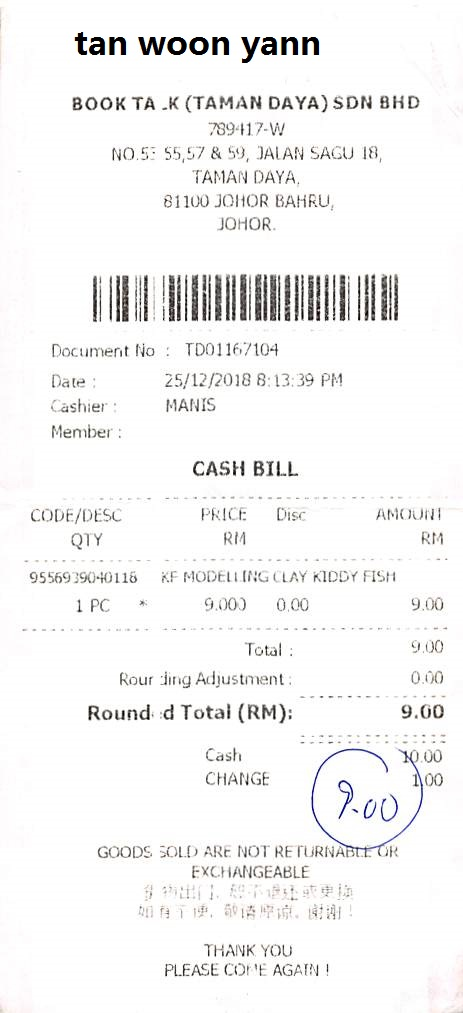

In [5]:
# Inspect the annotation schema before evaluation.
print(ds["train"].features)
print("Example annotation:")
print(ds["train"][0])
print("Example image:")
display(ds_images["train"][0]["image"])


In [6]:
def image_to_cv2(image_value: Any) -> np.ndarray:
    # Convert a PIL image or NumPy image to OpenCV BGR/grayscale.
    if hasattr(image_value, "convert"):
        rgb = np.asarray(image_value.convert("RGB"))
        return cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

    if isinstance(image_value, np.ndarray):
        image = np.ascontiguousarray(image_value)
        if image.ndim == 2:
            return image
        if image.ndim == 3 and image.shape[2] == 3:
            return image
        if image.ndim == 3 and image.shape[2] == 4:
            return cv2.cvtColor(image, cv2.COLOR_BGRA2BGR)
        raise ValueError(f"Unsupported NumPy image shape: {image.shape}")

    raise TypeError(f"Unsupported image type: {type(image_value).__name__}")


def resize_for_ocr(gray: np.ndarray, min_height: int = 64, max_height: int = 4000) -> np.ndarray:
    if gray.ndim != 2:
        raise ValueError(f"Expected grayscale image, got shape {gray.shape}")
    height, width = gray.shape
    if height <= 0 or width <= 0:
        raise ValueError("Image has invalid dimensions.")
    if min_height <= height <= max_height:
        return gray
    scale = min_height / height if height < min_height else max_height / height
    size = (max(1, round(width * scale)), max(1, round(height * scale)))
    interpolation = cv2.INTER_CUBIC if scale > 1 else cv2.INTER_AREA
    return cv2.resize(gray, size, interpolation=interpolation)


def deskew(gray: np.ndarray, max_angle: float = 15.0) -> np.ndarray:
    # Deskew using a foreground mask, while preserving grayscale information.
    if gray.ndim != 2:
        raise ValueError("deskew expects a grayscale image")
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = np.column_stack(np.where(mask > 0))
    if len(coords) < 20:
        return gray
    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle
    if abs(angle) < 0.3 or abs(angle) > max_angle:
        return gray
    h, w = gray.shape
    matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(gray, matrix, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)


def preprocess_image(image: np.ndarray, mode: str = "gray") -> np.ndarray:
    gray = image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = resize_for_ocr(gray)
    if mode == "original":
        return image
    if mode == "gray":
        return gray
    if mode == "otsu":
        return cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    if mode == "adaptive":
        return cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 11)
    if mode == "deskew":
        return deskew(gray)
    raise ValueError(f"Unknown preprocessing mode: {mode}")


In [7]:
def run_tesseract(image: np.ndarray, lang: str = OCR_LANG, psm: int = OCR_PSM,
                  oem: int = OCR_OEM, timeout: int = 60) -> str:
    config = f"--oem {oem} --psm {psm}"
    return pytesseract.image_to_string(image, lang=lang, config=config, timeout=timeout).strip()


In [8]:
# Field normalization. This is used only for field comparisons, not for OCR text display.
def normalize_text(value: Any) -> str:
    if value is None:
        return ""
    text = unicodedata.normalize("NFKC", str(value)).casefold()
    text = text.replace("\u00a0", " ").replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_number(value: Any) -> str:
    if value is None:
        return ""
    text = str(value).strip()
    negative = text.startswith("(") and text.endswith(")")
    text = re.sub(r"[^0-9,.-]", "", text)
    if not text:
        return ""
    if "," in text and "." in text:
        if text.rfind(",") > text.rfind("."):
            text = text.replace(".", "").replace(",", ".")
        else:
            text = text.replace(",", "")
    elif text.count(",") == 1 and len(text.rsplit(",", 1)[1]) <= 2:
        text = text.replace(",", ".")
    else:
        text = text.replace(",", "")
    try:
        number = float(text)
        if negative:
            number = -number
        return f"{number:.2f}"
    except ValueError:
        return ""


def normalize_date(value: Any) -> str:
    text = normalize_text(value)
    match = re.search(r"\b(\d{1,4})[./-](\d{1,2})[./-](\d{1,4})\b", text)
    if not match:
        return text
    parts = [int(x) for x in match.groups()]
    if len(str(parts[0])) == 4:
        year, month, day = parts
    else:
        day, month, year = parts
        if year < 100:
            year += 2000
    try:
        return datetime(year, month, day).date().isoformat()
    except ValueError:
        return text


def normalize_field(value: Any, field: str) -> str:
    if field == "total":
        return normalize_number(value)
    if field == "date":
        return normalize_date(value)
    # Ignore punctuation for company/address comparison, but preserve words and digits.
    text = normalize_text(value)
    return re.sub(r"[^\w\s]", "", text)


def field_similarity(reference: Any, prediction: Any, field: str) -> float:
    ref, pred = normalize_field(reference, field), normalize_field(prediction, field)
    if not ref and not pred:
        return 1.0
    if not ref or not pred:
        return 0.0
    return SequenceMatcher(None, ref, pred).ratio()


def field_exact(reference: Any, prediction: Any, field: str) -> bool:
    return normalize_field(reference, field) == normalize_field(prediction, field)


In [9]:
DATE_RE = re.compile(r"\b\d{1,2}[./-]\d{1,2}[./-]\d{2,4}\b")
TOTAL_LABEL_RE = re.compile(r"(?i)\b(?:grand\s+total|rounded\s+total|total\s+inclusive|total\s+incl|amount\s+due|total)\b")
TOTAL_NUMBER_RE = re.compile(r"(?<!\w)-?\d[\d,]*(?:\.\d{1,2})?(?!\w)")
STOP_RE = re.compile(r"(?i)\b(?:tax invoice|invoice|receipt|date|time|tel|telephone|phone|gst|cashier|member|document|doc|total|subtotal|sub-total)\b")
COMPANY_HINT_RE = re.compile(r"(?i)\b(?:sdn\s+bhd|trading|marketing|hardware|enterprise|handel|berhad|ltd|limited|inc|corp)\b")


def meaningful_lines(ocr_text: str) -> list[str]:
    lines = [re.sub(r"\s+", " ", line).strip() for line in ocr_text.splitlines()]
    return [line for line in lines if line]


def extract_invoice_fields(ocr_text: str) -> dict[str, str]:
    # Extract the four benchmark fields using invoice header/total structure.
    lines = meaningful_lines(ocr_text)
    if not lines:
        return {field: "" for field in FIELDS}

    # Prefer a business-name-looking line in the first eight lines; otherwise use
    # the first line with enough alphabetic content and no obvious OCR noise.
    company_index = 0
    for i, line in enumerate(lines[:8]):
        if COMPANY_HINT_RE.search(line):
            company_index = i
            break
    else:
        candidates = [(i, line) for i, line in enumerate(lines[:8])
                      if len(re.findall(r"[A-Za-z]", line)) >= 4 and not STOP_RE.search(line)]
        if candidates:
            company_index = candidates[0][0]

    company = lines[company_index]

    # Address is the header block after the company and before document metadata.
    address_lines = []
    for line in lines[company_index + 1:]:
        if STOP_RE.search(line):
            break
        if DATE_RE.search(line):
            break
        if len(re.findall(r"[A-Za-z]", line)) >= 3 or re.search(r"\d", line):
            address_lines.append(line)
    address = " ".join(address_lines)

    # Prefer a date near a date label; otherwise use the first plausible date.
    date = ""
    for line in lines:
        if re.search(r"(?i)\bdate\b", line) and DATE_RE.search(line):
            date = DATE_RE.search(line).group(0)
            break
    if not date:
        for line in lines:
            match = DATE_RE.search(line)
            if match:
                date = match.group(0)
                break

    # Prefer final-total labels over generic total labels and take the last number
    # on that line. This avoids capturing 'Total Quantity' or an earlier subtotal.
    total = ""
    priority_patterns = [
        re.compile(r"(?i)\b(?:grand\s+total|rounded\s+total|total\s+inclusive|total\s+incl)\b"),
        re.compile(r"(?i)\b(?:amount\s+due|total)\b"),
    ]
    for pattern in priority_patterns:
        matching_lines = [line for line in lines if pattern.search(line) and not re.search(r"(?i)total\s+quantity", line)]
        if matching_lines:
            numbers = TOTAL_NUMBER_RE.findall(matching_lines[-1])
            if numbers:
                total = numbers[-1]
                break

    return {"company": company, "date": date, "address": address, "total": total}


In [10]:
def compare_fields(reference: dict[str, Any], prediction: dict[str, Any]) -> dict[str, Any]:
    exact, similarity = {}, {}
    for field in FIELDS:
        exact[field] = field_exact(reference.get(field, ""), prediction.get(field, ""), field)
        similarity[field] = field_similarity(reference.get(field, ""), prediction.get(field, ""), field)
    return {"exact": exact, "similarity": similarity}


def edit_distance(a, b):
    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        current = [i]
        for j, cb in enumerate(b, 1):
            current.append(min(current[-1] + 1, previous[j] + 1, previous[j - 1] + (ca != cb)))
        previous = current
    return previous[-1]


def error_rate(reference: str, prediction: str, unit: str) -> float:
    ref = reference if unit == "char" else reference.split()
    pred = prediction if unit == "char" else prediction.split()
    return edit_distance(ref, pred) / max(len(ref), 1)


def evaluate_dataset(max_samples=None, preprocess_mode="gray"):
    n_samples = len(ds_images["train"]) if max_samples is None else min(max_samples, len(ds_images["train"]))
    results = []
    for start in range(0, n_samples, 25):
        end = min(start + 25, n_samples)
        with tqdm(range(start, end), total=end - start, desc=f"Images {start + 1}-{end}", unit="image") as bar:
            for i in bar:
                image = image_to_cv2(ds_images["train"]["image"][i])
                reference = dict(ds["train"]["entities"][i])
                original_text = run_tesseract(image)
                processed = preprocess_image(image, preprocess_mode)
                processed_text = run_tesseract(processed)
                original_fields = extract_invoice_fields(original_text)
                processed_fields = extract_invoice_fields(processed_text)
                results.append({
                    "index": i,
                    "reference": reference,
                    "original": {"text": original_text, "fields": original_fields, "comparison": compare_fields(reference, original_fields)},
                    "processed": {"text": processed_text, "fields": processed_fields, "comparison": compare_fields(reference, processed_fields)},
                })
    return results


In [11]:
def summarize_results(results):
    summary = {"samples": len(results), "original": {}, "processed": {}}
    for variant in ("original", "processed"):
        exact_by_field = {field: [] for field in FIELDS}
        similarity_by_field = {field: [] for field in FIELDS}
        for row in results:
            for field in FIELDS:
                exact_by_field[field].append(float(row[variant]["comparison"]["exact"][field]))
                similarity_by_field[field].append(row[variant]["comparison"]["similarity"][field])
        summary[variant] = {
            "field_accuracy_macro": float(np.mean([np.mean(v) for v in exact_by_field.values()])),
            "per_field_exact_accuracy": {f: float(np.mean(v)) for f, v in exact_by_field.items()},
            "per_field_similarity": {f: float(np.mean(v)) for f, v in similarity_by_field.items()},
        }
    summary["improvement_processed_minus_original"] = {
        field: summary["processed"]["per_field_exact_accuracy"][field] - summary["original"]["per_field_exact_accuracy"][field]
        for field in FIELDS
    }
    return summary


def show_worst_results(results, variant="processed", field="address", number_to_show=10):
    ranked = sorted(results, key=lambda row: row[variant]["comparison"]["similarity"][field])[:number_to_show]
    for row in ranked:
        i = row["index"]
        print(f"\nIndex: {i} | {field} similarity: {row[variant]['comparison']['similarity'][field]:.3f}")
        print("Expected:", row["reference"].get(field, ""))
        print("Predicted:", row[variant]["fields"].get(field, ""))


In [12]:
# Run the benchmark.
results = evaluate_dataset(MAX_SAMPLES, PREPROCESS_MODE)
summary = summarize_results(results)
print(json.dumps(summary, indent=2))


Images 1-25:   0%|          | 0/25 [00:00<?, ?image/s]

Images 26-50:   0%|          | 0/25 [00:00<?, ?image/s]

Images 51-75:   0%|          | 0/25 [00:00<?, ?image/s]

Images 76-100:   0%|          | 0/25 [00:00<?, ?image/s]

Images 101-125:   0%|          | 0/25 [00:00<?, ?image/s]

...

Images 701-725:   0%|          | 0/25 [00:00<?, ?image/s]

Images 726-750:   0%|          | 0/25 [00:00<?, ?image/s]

Images 751-775:   0%|          | 0/25 [00:00<?, ?image/s]

Images 776-778:   0%|          | 0/3 [00:00<?, ?image/s]

{
  "samples": 778,
  "original": {
    "field_accuracy_macro": 0.3653598971722365,
    "per_field_exact_accuracy": {
      "company": 0.2712082262210797,
      "date": 0.6760925449871465,
      "address": 0.05912596401028278,
      "total": 0.455012853470437
    },
    "per_field_similarity": {
      "company": 0.7291318478376309,
      "date": 0.7570361586207568,
      "address": 0.725626948354628,
      "total": 0.6891394666458933
    }
  },
  "processed": {
    "field_accuracy_macro": 0.37339331619537275,
    "per_field_exact_accuracy": {
      "company": 0.2750642673521851,
      "date": 0.6850899742930592,
      "address": 0.06683804627249357,
      "total": 0.4665809768637532
    },
    "per_field_similarity": {
      "company": 0.7325638611641975,
      "date": 0.7633520011531425,
      "address": 0.728542855135311,
      "total": 0.6926313546493494
    }
  },
  "improvement_processed_minus_original": {
    "company": 0.003856041131105381,
    "date": 0.00899742930591263,
    "

In [13]:
# Inspect the weakest address predictions, then repeat with company/total if needed.
show_worst_results(results, variant="processed", field="address", number_to_show=10)



Index: 10 | address similarity: 0.000
Expected: KM 458.4 BKT LANJAN UTARA, L/RAYA UTARA SELATAN,SG BULOH 47000 SUNGAI BUL
Predicted: 

Index: 88 | address similarity: 0.000
Expected: NO 8, JALAN 7/118B, DESA TUN RAZAK 56000 KUALA LUMPUR, MALAYSIA
Predicted: 

Index: 93 | address similarity: 0.000
Expected: NO 8, JALAN 7/118B, DESA TUN RAZAK 56000 KUALA LUMPUR, MALAYSIA
Predicted: 

Index: 94 | address similarity: 0.000
Expected: NO 8, JALAN 7/118B, DESA TUN RAZAK 56000 KUALA LUMPUR, MALAYSIA
Predicted: 

Index: 111 | address similarity: 0.000
Expected: NO. 42, JALAN PBS 14/11, TAMAN PERINDUSTRIAN BUKIT SERDANG, 43300 SERI KEMBANGAN, SELANGOR
Predicted: 

Index: 119 | address similarity: 0.000
Expected: NO 8, JALAN 7/118B, DESA TUN RAZAK 56000 KUALA LUMPUR, MALAYSIA
Predicted: 

Index: 121 | address similarity: 0.000
Expected: NO 8, JALAN 7/118B, DESA TUN RAZAK 56000 KUALA LUMPUR, MALAYSIA
Predicted: 

Index: 211 | address similarity: 0.000
Expected: NO.J-G-02, SOHO KI, SOLARIS MONT KI

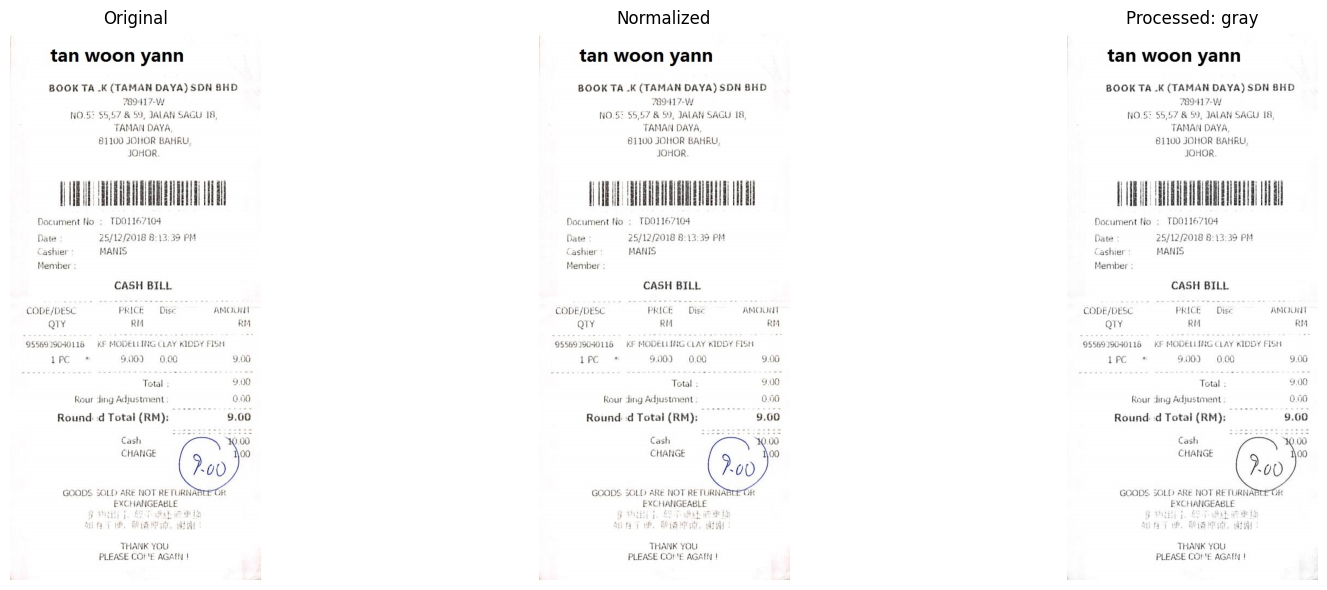

Reference: {'company': 'BOOK TA .K (TAMAN DAYA) SDN BHD', 'date': '25/12/2018', 'address': 'NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.', 'total': '9.00'}
Extracted: {'company': 'BOOK TA -K (TAMAN DAYA) SDN BHD', 'date': '25/12/2018', 'address': '78941 7-W NO.5? 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR. WAM MUTE A', 'total': '9.60'}


In [14]:
# Visual comparison for one invoice.
INDEX_TO_VIEW = 0
sample = ds_images["train"]["image"][INDEX_TO_VIEW]
image_bgr = image_to_cv2(sample)
processed = preprocess_image(image_bgr, PREPROCESS_MODE)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(sample)
axes[0].set_title("Original")
axes[1].imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB) if image_bgr.ndim == 3 else image_bgr, cmap="gray")
axes[1].set_title("Normalized")
axes[2].imshow(processed, cmap="gray" if processed.ndim == 2 else None)
axes[2].set_title(f"Processed: {PREPROCESS_MODE}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Reference:", ds["train"]["entities"][INDEX_TO_VIEW])
print("Extracted:", extract_invoice_fields(run_tesseract(processed)))


## How to interpret the results

Use `per_field_exact_accuracy` as the headline metric for this structured task. Use `per_field_similarity` to distinguish a near miss from a completely missing field. CER/WER on the full invoice are diagnostic only and should not be used as the primary score for dictionary annotations.

If address accuracy remains low after this fix, inspect the worst examples. The next improvement should be region-based extraction using Tesseract word boxes (`pytesseract.image_to_data`) or the dataset's `ocr_boxes`, rather than more global thresholding.
